In [ ]:
import warnings
# Глушым стандартны клас папярэджанняў Python
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Глушым любыя папярэджанні, якія ўтрымліваюць тэкст пра eval_set
warnings.filterwarnings("ignore", message=".*eval_set.*is deprecated.*")

warnings.filterwarnings("ignore", category=UserWarning)
# Асобна для LightGBM, бо ён выкарыстоўвае свой тып папярэджанняў:

from lightgbm.basic import LightGBMError
import lightgbm as lgb
warnings.filterwarnings("ignore", module="lightgbm")


In [2]:
import gc
import matplotlib.pyplot as plt
import sys

import numpy as np
from pathlib import Path

from IPython.display import Image, display


from modules import (
    BayesianTuner,
    ClassifierBench,
    DataVisualizer,
    ModelEvaluator,
    PrepareDataset,    
)
    

ROOT = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd() # рашэнне для .ipny  і .py
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

DATA = ROOT / "data"
OUT = ROOT / "output"
OUT.mkdir(parents=True, exist_ok=True)

evaluator = ModelEvaluator()
bench = ClassifierBench()
viz = DataVisualizer(OUT)
dataset = PrepareDataset(DATA)

### 1. Датасет Online Shoppers Purchasing Intention

In [3]:
   
file_name="online_shoppers_intention.csv"

frame = dataset.load_csv(file_name=file_name)
frame.head(2)

print(f"Крыніца даных: {DATA/file_name}")

[LoadDataset] online_shoppers_intention.csv: 12330 радкоў x 18 слупкоў
Крыніца даных: d:\DScourse\hw4\data\online_shoppers_intention.csv


### 2. Падрыхтоўка даных
Падзел спосабам 'static_3way' (60/20/20), падзел пад CV+holdout  
Вызначэнне правіл маштабавання

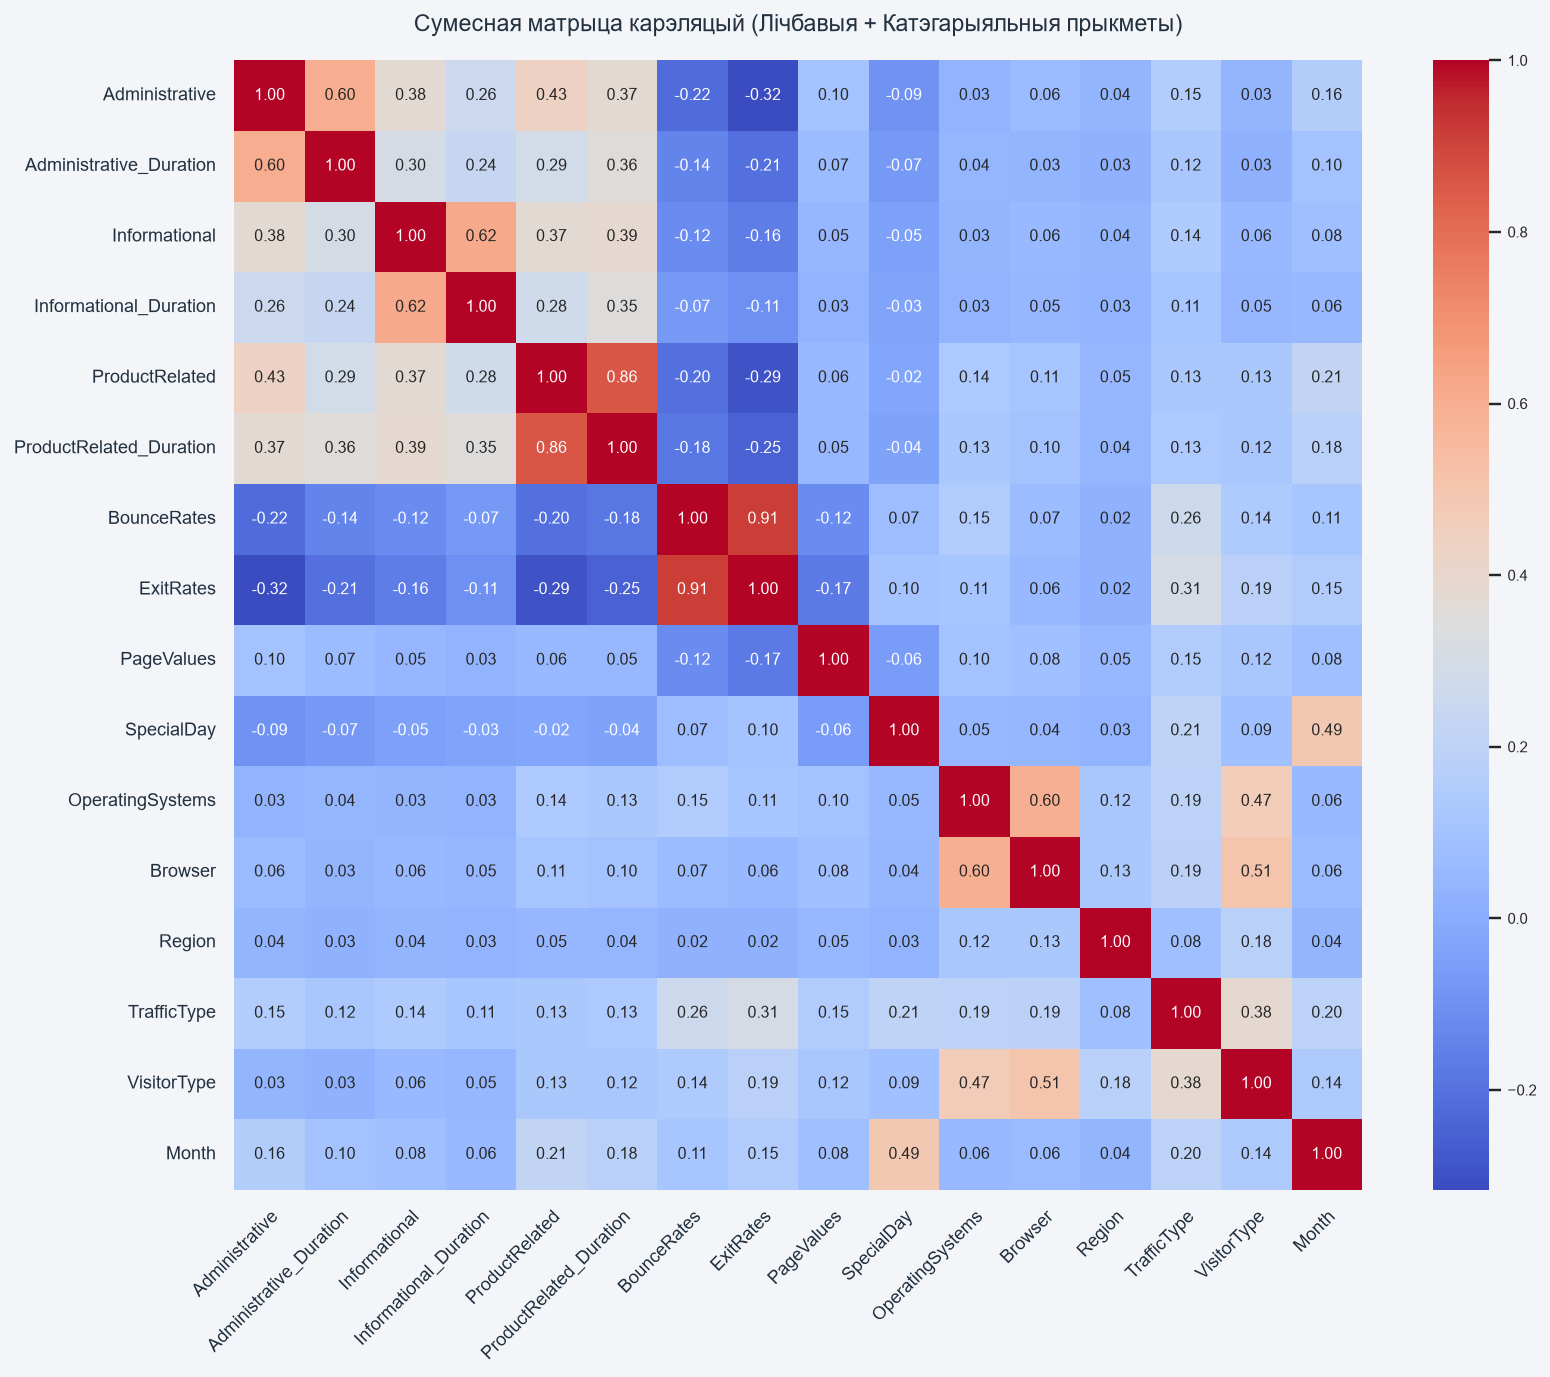

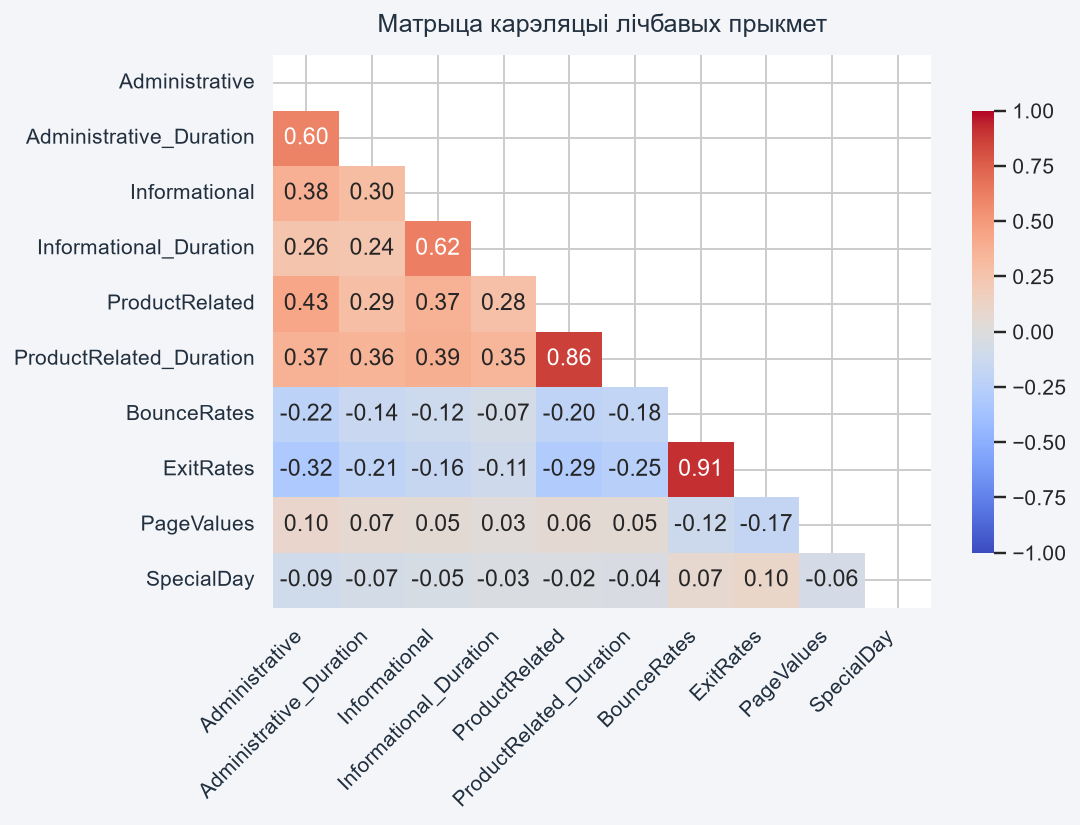

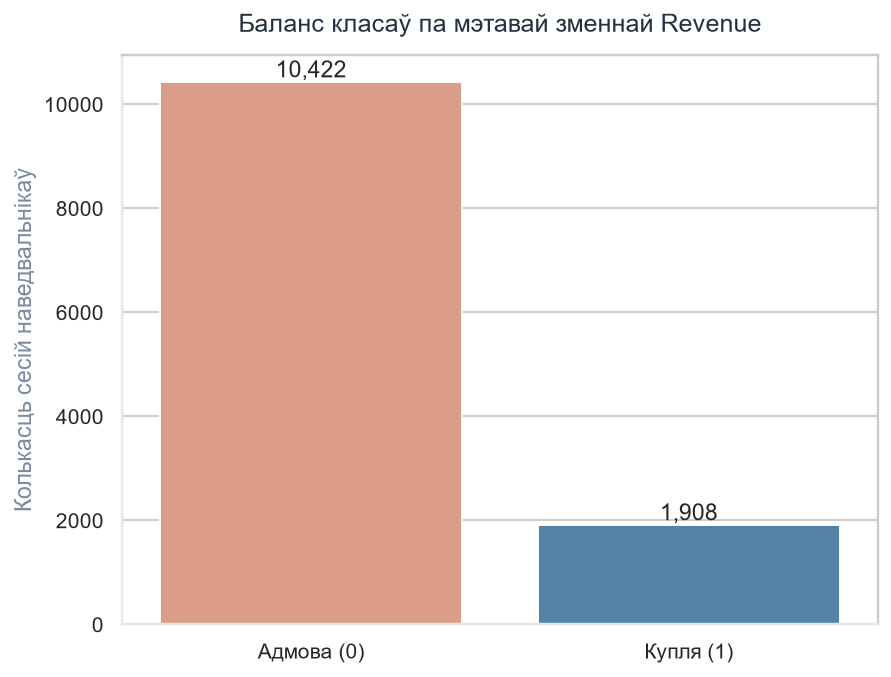

[PrepareDataset] Колькасць радкоў у даных 12330, з іх
(Купля: 1908 (Revenue==1), што склала (15.474%), 
(Адмова: 10422 (Revenue==0)
[PrepareDataset] Падзел static_3way (60/20/20): train=7398, val=2466, test=2466
               Размеркаванне (Revenue==1) па выбарках: train = 1145, val=381, test=382
[PrepareDataset] Падзел пад СV + hold out: CV=9864, test=2466
               Размеркаванне (Revenue==1) па выбарках: СV = 1526, test=382
[PrepareDataset] Даныя не масштабаваліся на этапе падзелу выбаркі
[Classifier] Метады:
  Dummy Classifier — baseline
  LogisticRegression — лінейная
  SVM — лінейная
  KNN — простае дрэва
  DecisionTree — простае дрэва
  ExtraTrees   — бэггінг
  LightGBM, XGBoost — бустынг
[Classifier] Маштабаванне вагі станоўчага класа: scale_pos_weight=5.5. Перадаю параметрам для XGBoost


In [4]:
target_name = "Revenue"

# Будуем матрыцу карэляцыі для ўсіх прыкмет, выключыўшы таргет "Revenue"

plot_path = viz.plot_correlation_matrix(x_train=frame.iloc[:, :-1], filename="CM_frame.png")
display(Image(filename=plot_path))

# матрыца карэляцыі лічбавых прыкмет
plot_path2 = viz.plot_pirson_correlation_matrix(x_train=frame.iloc[:, :-1], filename="CM_frame_num.png")
display(Image(filename=plot_path2))    

ohe_feature_list = ["OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType"]
known_categories = {
    col: sorted(list(frame[col].dropna().unique())) for col in ohe_feature_list
}

plot_path = viz.plot_class_balance(frame[target_name], name=target_name)
display(Image(filename=plot_path))

split = dataset.prepare(frame, target_name = target_name, test_size = 0.2, val_size = 0.2, random_state=42)   

bench.build(split.y_train)

bench.preprocessor = dataset.create_preprocessor(categories_dict=known_categories)

Высновы:
 * 2.1 Умераны дысбаланс класаў: 15%
 * 2.2 Моцна скарэляваныя прыкметы:  
        0.91 паміж парай Bounce Rates (паказчык адмоваў) і Exit Rates (паказчык выхаду). Exit Rates - больш інфарматыўная для мадэлі  
        0.84 паміж ProductRelated (колькасць прагледжаных старонак з таварамі за сесію) і ProductRelated_Duration (агульны час, праведзены на гэтых старонках). ProductRelated_Duration - утрымлівае анамальна высокія значэнні
 * 2.3 Датасэт змяшчае лічбавыя і катэгарыяльныя прыкметы, што вымагае маштабавання паводле прыроды метаду класіфікацыі       

Рашэнне:
 * 2.1 збудуем архітэктуру вакол тэмы дысбалансу і даследуем паводзіны класіфіктараў  
 * 2.2 Пакінем прыкметы ў поўным аб'еме у невялікім датасэце, зробім акцэнт на класіфікацыі ансамблевымі метадамі (ExtraTrees, XGBoost, LightGBM)
На лінейныя мадэлі і простыя дрэвы паглядзім для забаўкі.
 * 2.3 Вызначылі матэматычны скалер паводле прыроды сямействаў мадэляў
        Dummy - не патрабуе маштабавання.
        Для лічбавых прыкмет   
            LogisticRegression - StandardScaler()  
            KNN, SVM - RobustScaler()  
            DecisionTree, ExtraTrees, LightGBM, XGBoost - маштабавання лічбавых прыкмет не патрабуюць   
        Для катэгарыяльных прыкмет у залежнасці ад тыпу:        
            OneHotEncoder() - тэкставыя катэгорыі, лічбавыя катэгорыі (інтэрпрэтуем як катэгорыі, не лікі)  
            OrdinalEncoder() - скарысталі для прыкметы "Month" з указаннем парадку следвання месяцаў і з улікам асаблівасці напісання ('June')  
                months_order = ['Feb', 'Mar', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']  
            Бінарныя прыкметы пакінулі без змен        

Адкінутае для дэманстрацыі рашэнне:  
Зменім прыкметы, што дазволіць класіфікаваць усімі тыпамі метадаў  
1. Стварэнне адноснай метрыкі  
  Avg_Time_Per_Product = ProductRelated_Duration / "ProductRelated" + 1e-5  
2. Спіс калонак для выдалення (высокая карэляцыя 0.91 і 0.84)  
  columns_to_drop = ["BounceRates", "ProductRelated_Duration"]  
Вынікі: лінейныя алгарытмы і дрэвы працуюць добра, але па Сцюдэнту перамагае LightGBM    
Матрыца памылак на тэсце: 1822 | 262  
                            71 | 311  


### 3. Класіфікацыя на падзеле (60/20/20)

In [5]:
metrics_table = bench.evaluate_baseline_models(
        split=split,        
        evaluator=evaluator,
        random_state=42
    )
print("\n Параўноўчая табліца метрык для падзелу 60/20/20 ")
print(metrics_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

--- Запуск Dummy у якасці baseline ---
Маштабаванне прыкмет Dummy не патрабуе
--- Запуск Logistic Regression ---
Маштабаванне прыкмет абавязковае
--- Запуск SVM ---
Маштабаванне прыкмет абавязковае (Robust + Calibrated Config)
--- Запуск KNN ---
Маштабаванне прыкмет абавязковае (Robust + Calibrated Config)
--- Запуск Дрэва рашэнняў ---
Маштабаванне катэгарыяльных прыкмет абавязковае (Balanced + Raw Numeric)
--- Запускаем ансамбль ExtraTrees ---
Маштабаванне катэгарыяльных прыкмет абавязковае (Balanced + Raw Numeric)

 Параўноўчая табліца метрык для падзелу 60/20/20 
                               Мадэль  PR-AUC  ROC-AUC  Precision  Recall     F1     F2  Accuracy  Час (сек)
           DummyClassifier (Baseline)  0.1548   0.5013     0.1567  0.1575 0.1571 0.1573    0.7388     0.0364
       Logistic Regression (Balanced)  0.6706   0.9027     0.5259  0.7717 0.6255 0.7057    0.8573     0.7998
     SVM (Robust + Calibrated Config)  0.6731   0.9034     0.7337  0.3832 0.5034 0.4237    0.8832   

Высновы на статычным падзеле (60/20/20):

* DecisionTree (Balanced): Лідар па F1 (0.6816) і F2 (0.7672). Мадэль знайшла 83.73% усіх рэальных пакупнікоў (`Recall`) пры сярэдняй дакладнасці прагнозу (`Precision = 0.57`). Гэта лепшы выбар для максімізацыі прыбытку і ахопу аўдыторыі.

* Logistic Regression: Паказвае стабільны і збалансаваны вынік (PR-AUC = 0.6706, F1 = 0.6255) при добрым ахопе пакупнікоў (`Recall = 0.7717`). Галоўная перавага — высокая хуткасць навучання (0.47 сек).

* ExtraTrees (Ensemble): Лепшы паказчык па PR-AUC (0.6778) і Precision (0.7976). Прагноз пакупкі спраўджваецца з імавернасцю ~80%, што робіць мадэль ідэальнай для эканоміі маркетынгавага бюджэту (ацэнка персанальных зніжак). Аднак мае нізкі `Recall` (35.17%) і патрабуе больш часу (1.84 сек).

* SVM (Robust): Паказаў высокую дакладнасць (`Precision = 0.73`) і добрую хуткасць (0.35 сек), але мае нізкі ахоп (`Recall = 0.3832`), цалкам дублюючы хібы ExtraTrees.

* KNN (Distance): Галоўны аўтсайдар (PR-AUC = 0.5972). Паказаў самы доўгі час працы — 17.44 сек.  

Прамежкавае рашэнне для KNN: Скараціць час выканання да 0.2820 с можна, калі збудаваць дрэва, скарыстаўшы параметр algorithm='kd_tree'  
                            Мадэль  PR-AUC  ROC-AUC  Precision  Recall     F1     F2  Accuracy  Час (сек)  
  KNN (Robust + Distance Weights)  0.5972   0.8695     0.6250  0.5381 0.5783 0.5535    0.8788     0.2820 

Рашэнне: Мадэлі DecisionTree, LogisticRegression і ExtraTrees пакідаем да далейшага разгляду на крос-валідацыі. Мадэлі SVM і KNN адхіляем з-за нізкай эфектыўнасці і нізкай прадукцыйнасці KNN на даных непадрыхтаваных пад гэтыя мадэлі.

## 4. Класіфікацыя на Крос-Валідацыі праз StratifiedKFold(5)

In [6]:
CV_methods_names = ["LogisticRegression", "DecisionTree", "ExtraTrees", "LightGBM", "XGBoost"]
CV_configs = bench.prepare_final_models(models_to_keep=CV_methods_names)
    
fold_pr2, fold_roc2, oof_predictions = bench.cross_validate_newV(split.x_cv, split.y_cv, models_conf=CV_configs)

# табліца метрык PR i ROC
cv_metrics_table = bench.get_metrics_table()
print("\n[Cross-Validation] Табліца метрык PR i ROC на StratifiedKFold(5), адсартавана па метрыцы выбару PR-AUC:")
print(cv_metrics_table.to_string(index=False))

best_threshold, best_score = evaluator.optimize_threshold_for_fbeta(            
            y_true=split.y_cv, 
            oof_probas=oof_predictions["LightGBM"], 
            model_name="LightGBM",
            beta=2.0
        )

df_base_report = evaluator.compile_performance_report(
    y_true=split.y_cv, 
    probas_dict=oof_predictions, 
    threshold=best_threshold #0.20
)
print(df_base_report.to_string(index=False))

[Cross-Validation] LogisticRegression ...
     PR-AUC=0.6506 ± 0.0200
[Cross-Validation] DecisionTree ...
     PR-AUC=0.6644 ± 0.0175
[Cross-Validation] ExtraTrees ...
     PR-AUC=0.6768 ± 0.0112
[Cross-Validation] LightGBM ...
     PR-AUC=0.7512 ± 0.0181
[Cross-Validation] XGBoost ...
     PR-AUC=0.7504 ± 0.0170

[Cross-Validation] Табліца метрык PR i ROC на StratifiedKFold(5), адсартавана па метрыцы выбару PR-AUC:
             model PR-AUC (Mean ± STD) ROC-AUC (Mean ± STD)
          LightGBM     0.7512 ± 0.0181      0.9340 ± 0.0039
           XGBoost     0.7504 ± 0.0170      0.9332 ± 0.0037
        ExtraTrees     0.6768 ± 0.0112      0.9003 ± 0.0066
      DecisionTree     0.6644 ± 0.0175      0.9173 ± 0.0057
LogisticRegression     0.6506 ± 0.0200      0.9002 ± 0.0069

[Threshold Optimizer] Шукаем лепшы працоўны парог па F2 на OOF для LightGBM...
🎯 ЗНОЙДЗЕНЫ АПТЫМАЛЬНЫ ПАРОГ: 0.410 (Валідацыйны F2: 0.7632)
            Мадэль   PR-AUC  ROC-AUC  Precision   Recall       F1       F2  Acc

Высновы па метрыках на крос-валідацыі і аптымізацыі парога:

* Перавага градыентнага бустынгу (LightGBM і XGBoost): Мадэлі бустынгу паказалі вышэйшую якасць, забяспечыўшы ўзровень PR-AUC ~0.75.  Розніца паміж імі статыстычна неістотная.
 LightGBM займае першае месца ў рэйтынгу (PR-AUC = 0.7512, ROC-AUC = 0.9340) і дэманструе нізкую дысперсію метрык па фолдах (STD ±0.0181).  
 XGBoost (PR-AUC = 0.7504)

* Асаблівасці ансамбля ExtraTrees: дэманструе вышэйшую за іншыя мадэлі дакладнасць (Precision = 0.7043) . Мінімізуе колькасць памылковых спрацоўванняў (False Positives), аднак мае нізкую поўнату прагнозу (`Recall` = 0.4934). Гэты метад мэтазгодна выкарыстоўваць у маркетынгавых кампаніях з высокім коштам аднаго кантакту, дзе крытычна важная дакладнасць лакалізацыі мэтавай групы.

* Падзенне эфектыўнасці DecisionTree і Logistic Regression: На этапе крос-валідацыі дадзеныя мадэлі саступілі бустынгу. Хоць зніжэнне працоўнага парога дазволіла павялічыць іх поўнату (`Recall` да 82–86%), узровень дакладнасці  знізіўся (`Precision` да 44-50%)

Прамежкавыя высновы: Для LightGBM назіраем эфект аптымізацыі працоўнага парога (F2-Score): значэнне на ўзроўні 0.41 зрушыў баланс мадэлі ў бок павелічэння поўнаты. Выніковы F2-Score склаў 0.7632. Мадэль паспяхова ідэнтыфікуе 88.07% рэальных пакупнікоў (`Recall`), захоўваючы дакладнасць (`Precision`) на ўзроўні 49.75%.


Візуалізацыя вынікаў класіфікацыі на кроку крос-валідацыі

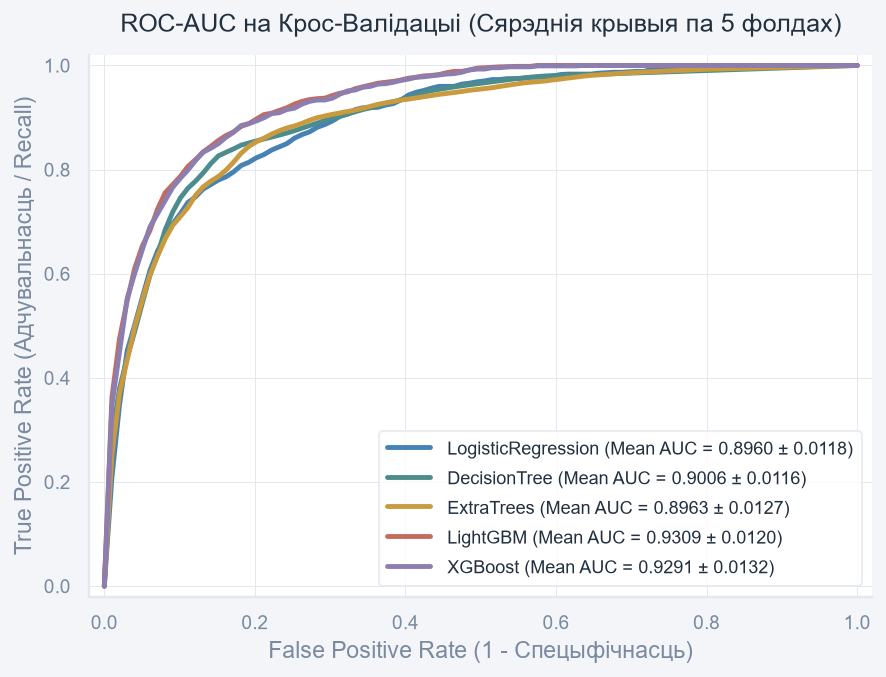

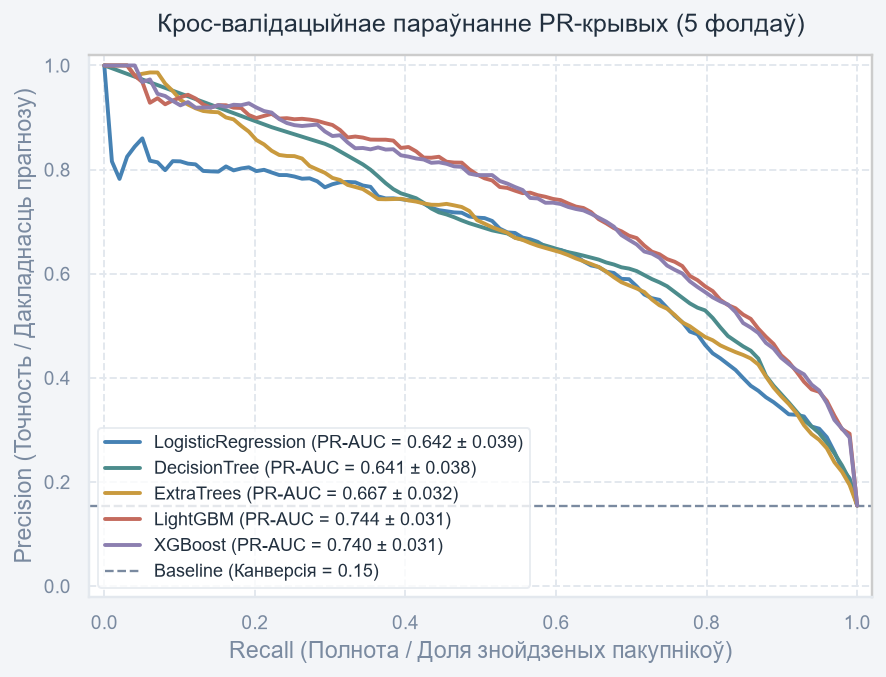

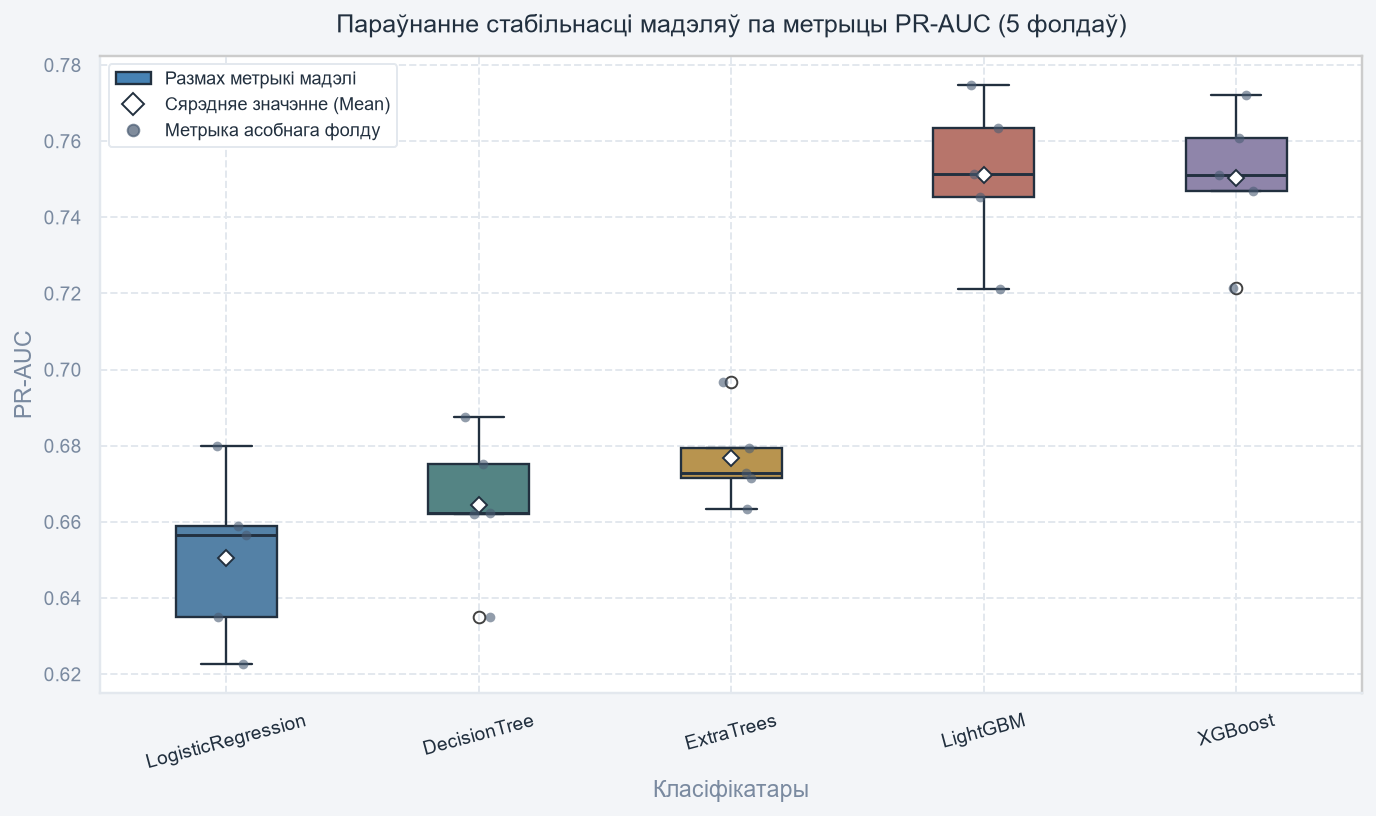

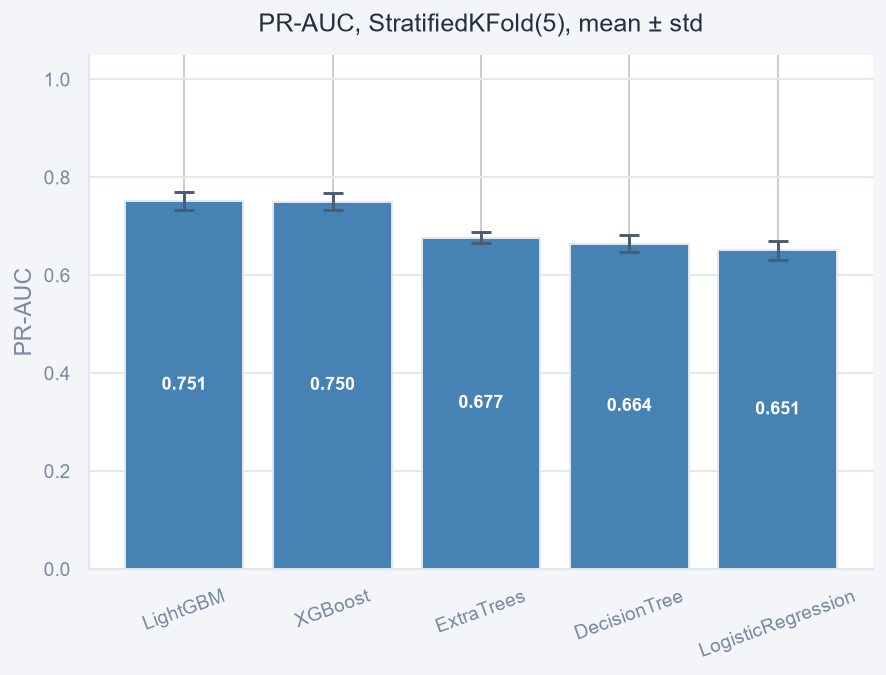

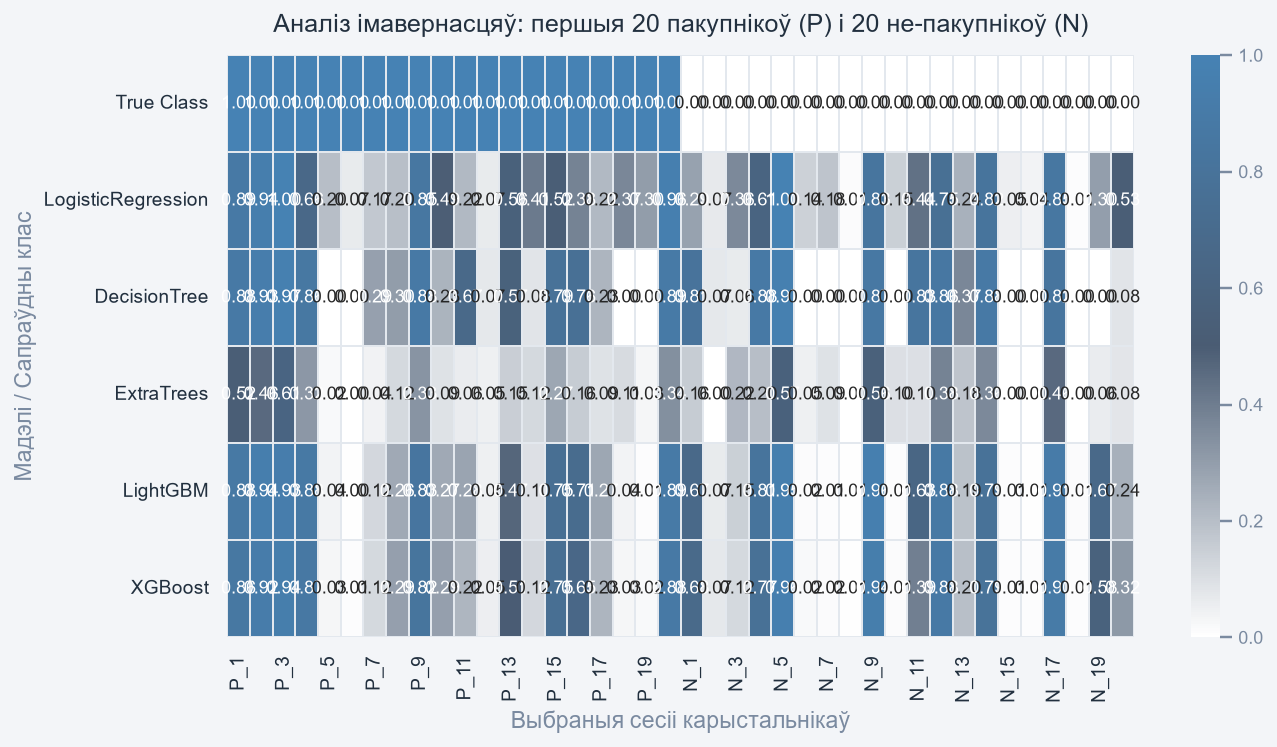


[Cross-Validation] Графік ранняга прыпынку па фолдах для бустынгаў


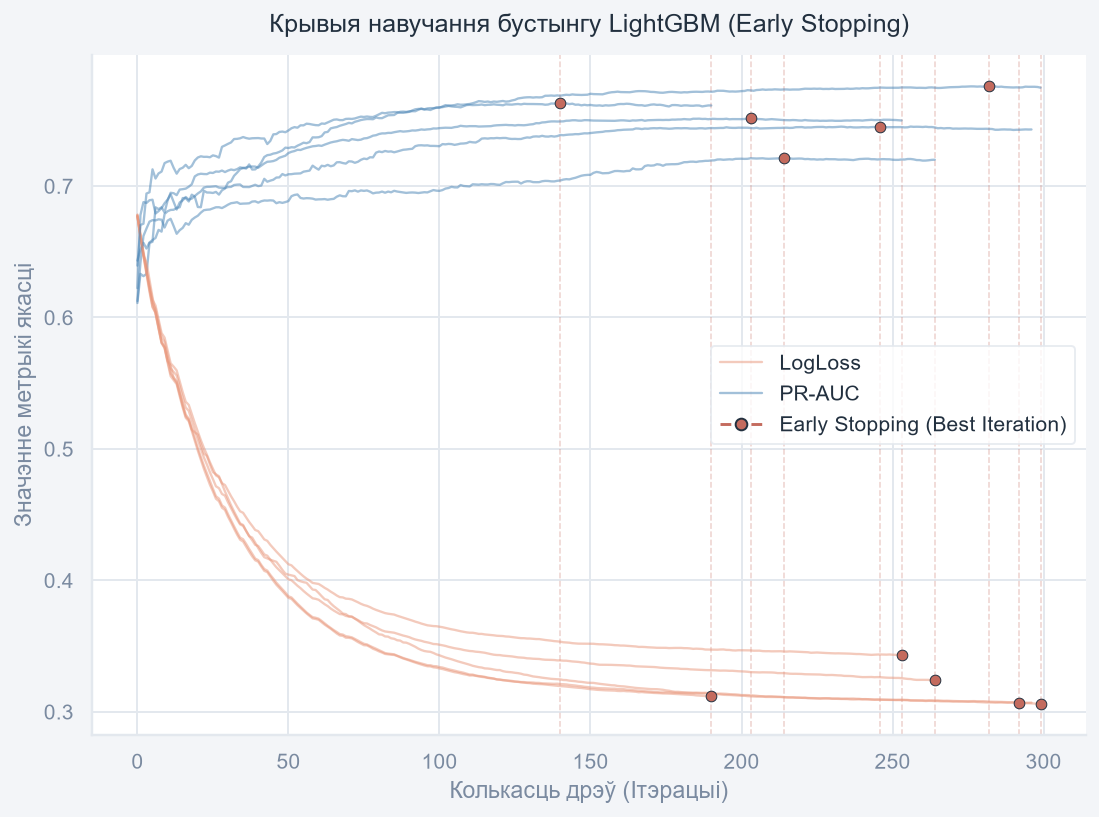


[Cross-Validation] Графік Train vs Validation для бустынгаў


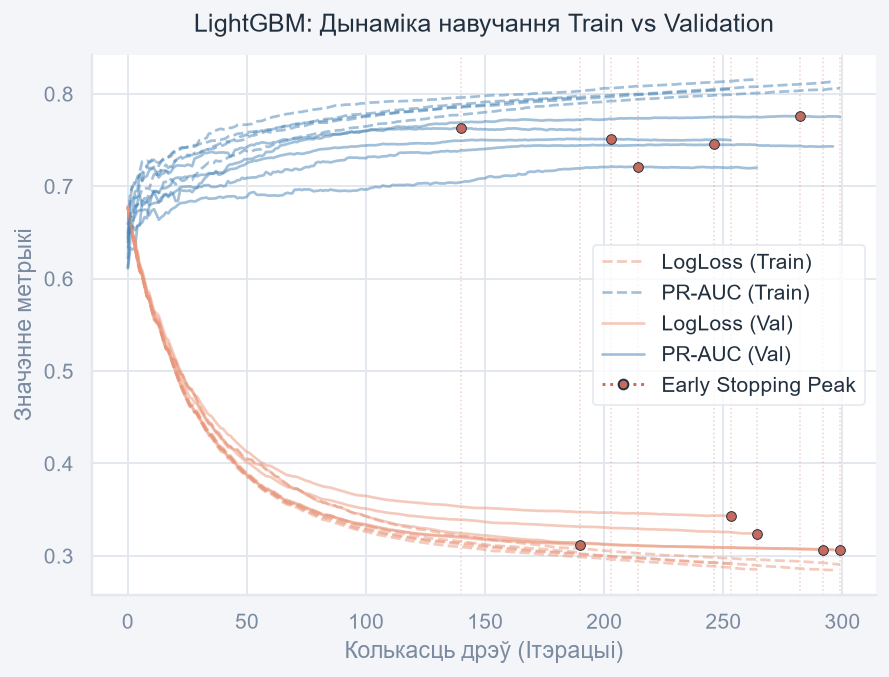


[Cross-Validation] Графік ранняга прыпынку па фолдах для бустынгаў


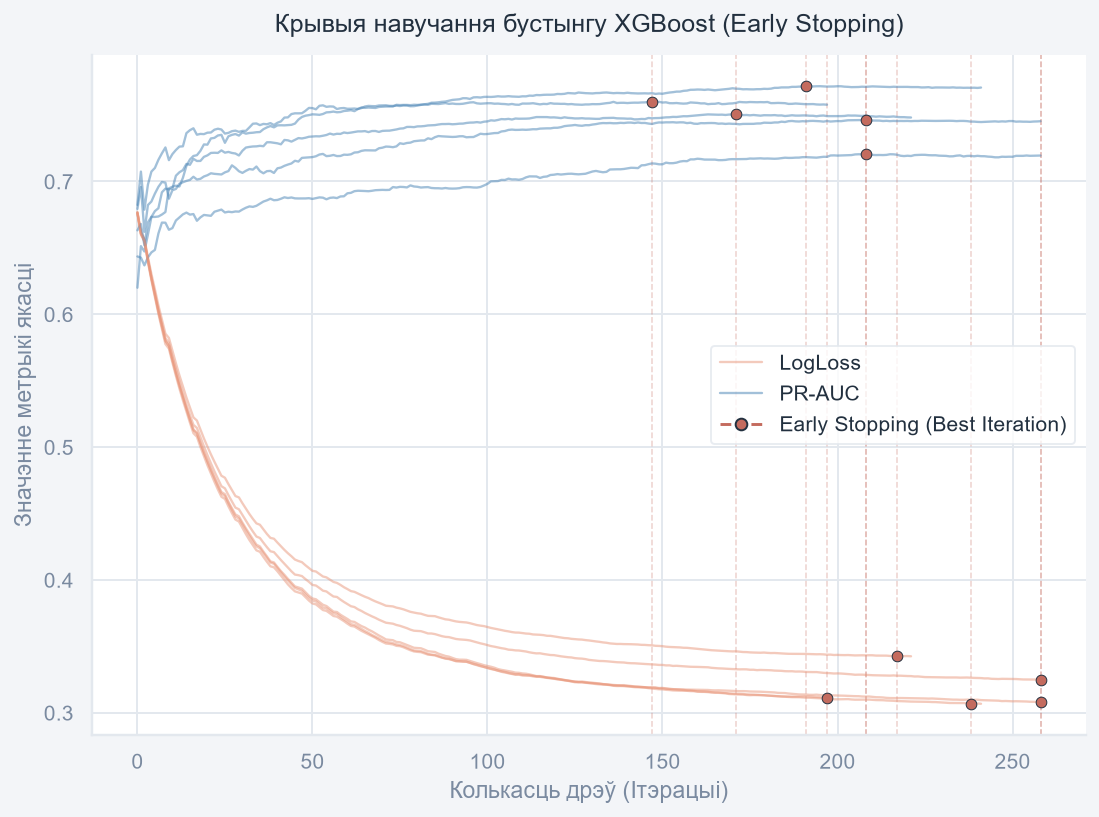


[Cross-Validation] Графік Train vs Validation для бустынгаў


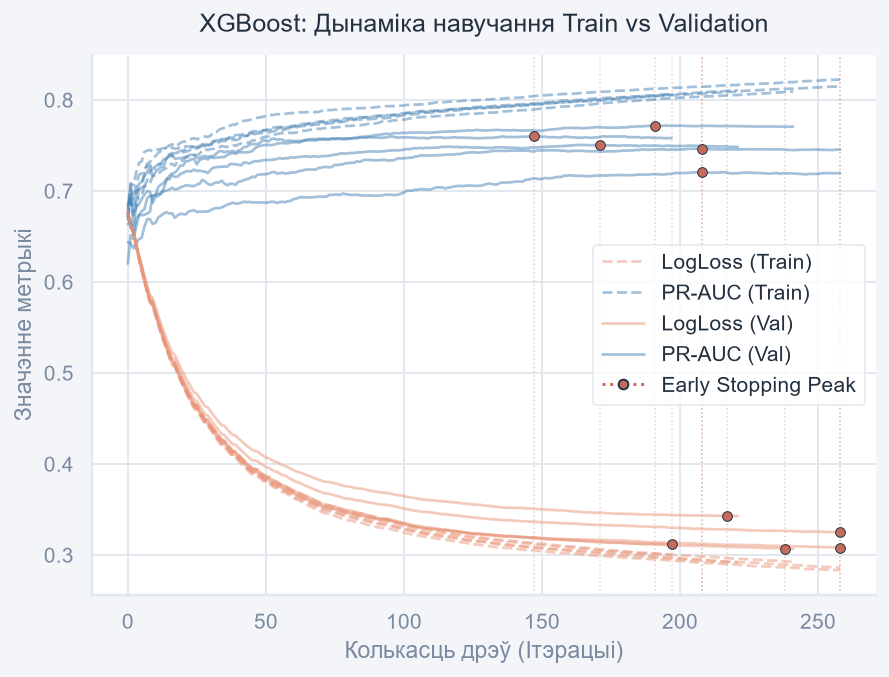

35

In [7]:
roc_plot_path = viz.plot_roc_curve_cv(x=split.x_train, y=split.y_train, models_dict=CV_configs, preprocessor=bench.preprocessor)    
display(Image(filename=roc_plot_path))

pr_curve_plot = viz.plot_pr_curve_cv(x=split.x_train, y=split.y_train, models_dict=CV_configs, preprocessor=bench.preprocessor)
display(Image(filename=pr_curve_plot))
    
boxplot = viz.plot_models_boxplot(fold_pr2, metric_name="PR-AUC", filename="models_stability_pr_auc.png")
display(Image(filename=boxplot))

cv_table = evaluator.cv_table(fold_pr2, fold_roc2)
cv_pr_auc = viz.plot_cv_pr_auc(cv_table)
display(Image(filename=cv_pr_auc))

path_heat = viz.plot_predictions_comparison(y_true=np.asarray(split.y_train), preds_dict=oof_predictions, num_samples_per_class=20)
display(Image(filename=path_heat))
    
if bench.cv_evals_results:
    for model_name, evals_data in bench.cv_evals_results.items():
        path_early_stopping = viz.plot_boosting_early_stopping(evals_result=evals_data, filename=f"cv_es_{model_name.lower()}.png")
        path_train_vs_val = viz.plot_boosting_train_vs_val(evals_result=evals_data, filename=f"train_vs_val_{model_name.lower()}.png")
        
        print("\n[Cross-Validation] Графік ранняга прыпынку па фолдах для бустынгаў")
        display(Image(filename=path_early_stopping))
        print("\n[Cross-Validation] Графік Train vs Validation для бустынгаў")
        display(Image(filename=path_train_vs_val))


plt.close('all')  # Закрываем усё, што магло выпадкова застацца адкрытым
gc.collect()      # Прымусова чысцім памяць прама ЗАРАЗ у галоўным патоку
    

Фокус: Крывыя навучання па 5 фолдах для Бустынгаў  

Высновы:  
Кропкі ранняга прыпынку на крывых PR-AUC і LogLoss, згрупаваныя і размешчаныя адна пад адной - добрая падказка для выбару аптымальнай колькасці дрэў для адпаведных метадаў.  
Рашэнне: скарыстаць для задання дыяпазону (n_estimators) на этапе падбору параметраў Optuna 

# 4.2 Выбар мадэлі па парным t-тэсце Сцюдэнта


[Evaluator] Парны t-тэст Сцюдэнта па фолдах: LightGBM vs XGBoost
t-статыстыка=0.951, p-value=0.3953
Парогавае значэнне t-статыстыкі = 2.776 - гэта мінімальны парог для t, які трэба перасягнуць, каб перастаць лічыць розніцу выпадковай
[Evaluator] У распрацоўку: LightGBM. 
 (p-value (0.3953) >= 0.05) Розніца НЕ значная паміж метадамі (t-статыстыка < 2.776 )


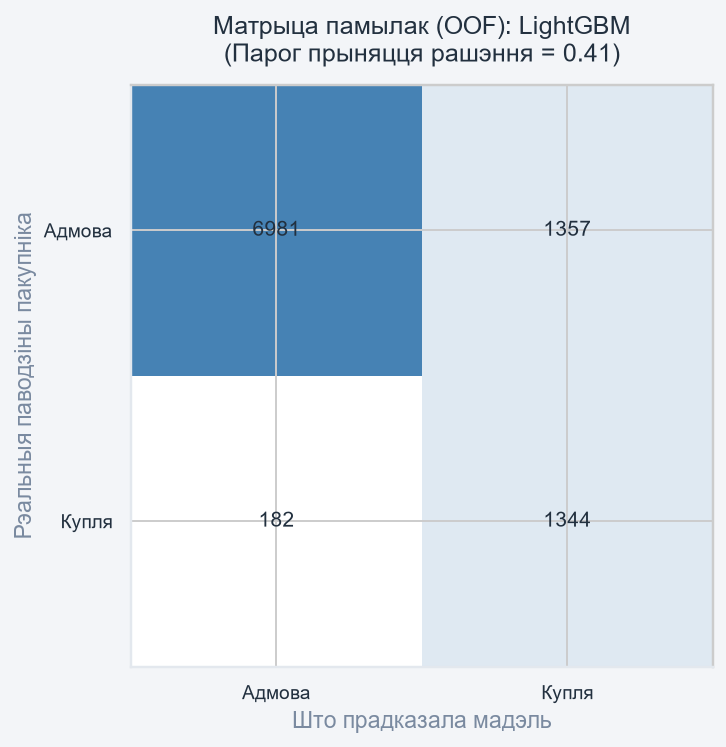

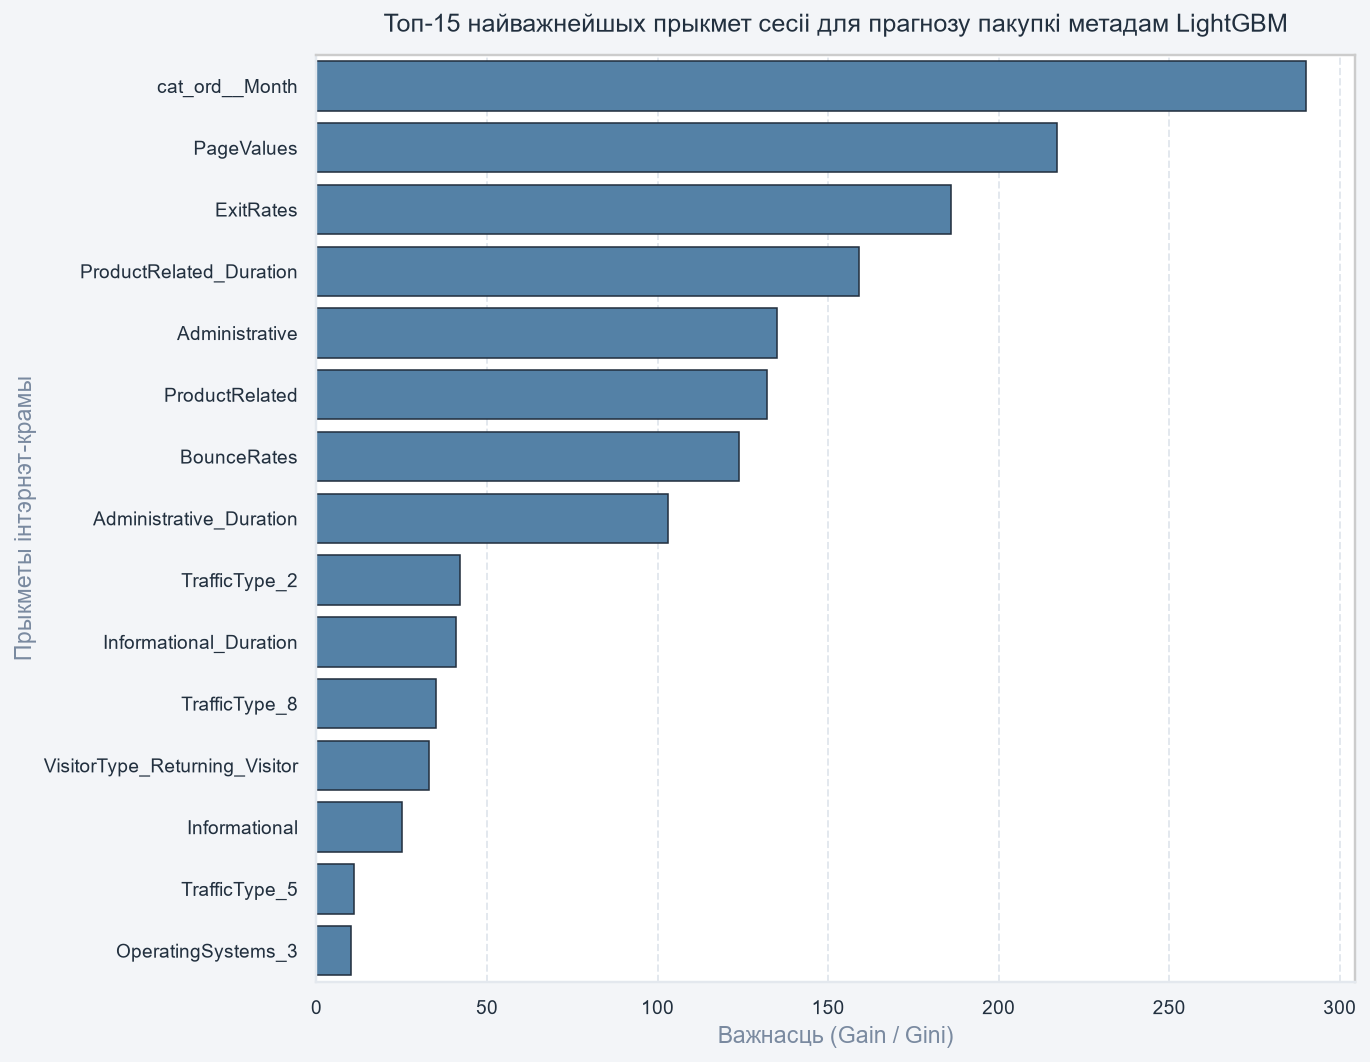

In [8]:
    # Выбар паміж двума лепшымі па PR
best_name = evaluator.pick_best(fold_pr2)   
    
    # Матрыца памылак для выбранай топ-мадэлі па яе імені карыстаецца гатовым вектарам імавернасцяў OOF
cm_path = viz.plot_classification_results(
    #y_true=split.y_cv, 
    y_true=split.y_cv.to_numpy(),
    y_probas=oof_predictions[best_name], 
    model_name=best_name,
    threshold=best_threshold,#0.20, # наладжваем парог пад нашы 15% канверсіі
    filename=f"confusion_matrix_{best_name}.png"
)
display(Image(filename=cm_path))

importance_path = viz.plot_feature_importance(model_pipeline=bench.fitted[best_name], model_name=best_name, filename=f"feature_importance_{best_name}.png")
display(Image(filename=importance_path))

Высновы: Тэст падказвае LightGBM, але абедзве мадэлі бустынгу выглядаюць статыстычна роўныя.  
З мэтай адпаведнасці заданню (выбар мадэлі па t-тэсце), схіляемся да LightGBM

### 4.3 Learning curves. Эфектыўнасць выкарыстання дадзеных
Праверка на перанавучанне метадаў. Залежнасць train/val score ад памеру выбаркі

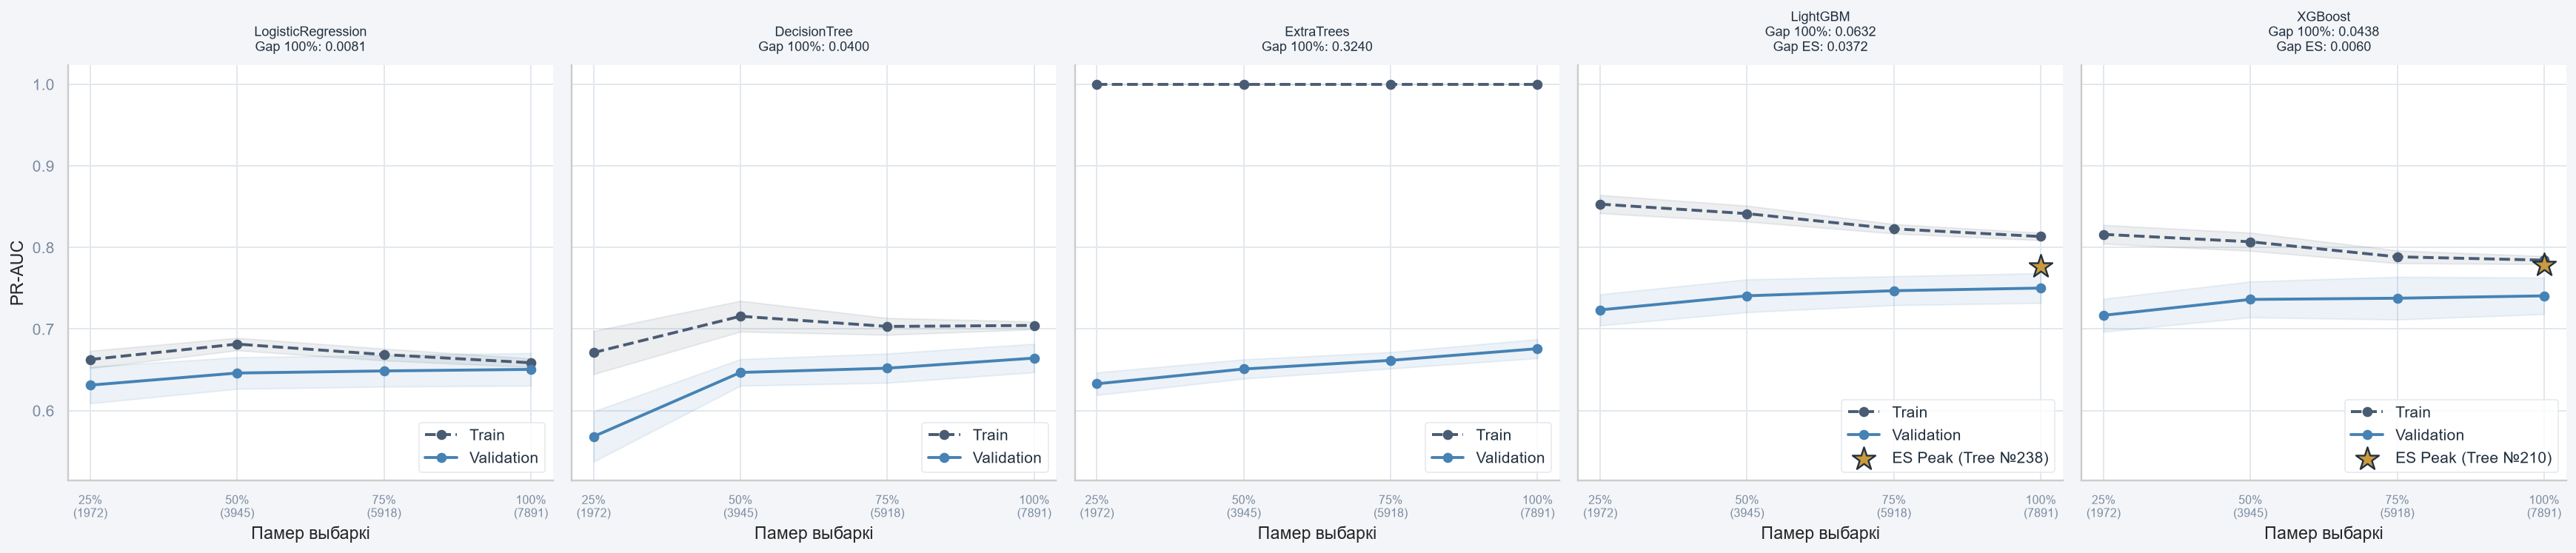

Параўнальны аналіз перанавучання (БЕЗ Early Stopping vs з улікам Early Stopping).
Высновы (ацэнка gap) па Early Stopping, калі ён мае месца быць, іначай напрыканцы кросвалідацыі на 100% (7891) даных, вылучаных пад яе
            Мадэль Gap 100% (Без EarlStop) Gap EarlStop (Працоўны) Кропка прыпынку      Высновы
           XGBoost                  0.0438                  0.0060      Дрэва №210 (gap < 0.05)
          LightGBM                  0.0632                  0.0372      Дрэва №238 (gap < 0.05)
      DecisionTree                  0.0400                       -       Не выкар. (gap < 0.05)
LogisticRegression                  0.0081                       -       Не выкар. (gap < 0.05)
        ExtraTrees                  0.3240                       -       Не выкар.   gap > 0.10


58165

In [9]:
LC_methods_names = ["LogisticRegression", "DecisionTree", "ExtraTrees", "LightGBM", "XGBoost"]
    
learning_curves_data_ES = bench.collect_learning_curves_ES(split.x_cv, split.y_cv, LC_methods_names)
        
path_es = viz.plot_learning_curves_ES(learning_curves_data_ES, filename="models_learning_curves_ES.png")
display(Image(filename=path_es))
        
print("Параўнальны аналіз перанавучання (БЕЗ Early Stopping vs з улікам Early Stopping).")
print("Высновы (ацэнка gap) па Early Stopping, калі ён мае месца быць, іначай напрыканцы кросвалідацыі на 100% (7891) даных, вылучаных пад яе")
                
df_comparison = bench.analyze_learning_gaps_table(learning_curves_data_ES)
print(df_comparison.to_string(index=False))
    
plt.close('all')  # Закрываем усё, што магло выпадкова застацца адкрытым
gc.collect()      # Прымусова чысцім памяць прама ЗАРАЗ у галоўным патоку

**Аналіз метадаў "LogisticRegression", "DecisionTree", "ExtraTrees", "LightGBM", "XGBoost"**  

Крывыя навучання паказваюць PR-AUC атрыманы на трэйне і валідацыі у залежнасці ад памеру выбаркі.
Разглядаем метады "LightGBM", "XGBoost" улічваючы значэнне ранняга прыпынку, атрыманага на кроку папярэдняга навучання.

Logistic Regression - неданавучанне мадэлі няма, мадэль насычаецца, патэнцыял росту для мадэлі малы: малы гэп на нізкім узроўні (Train = 0.68, Val = 0.63)

"DecisionTree" - мадэль абмежавана памерам выбаркі, мае патэнцыял для росту з павелічэннем аб'ему даных (Val = 0.67)

"ExtraTrees" - карыснае перанавучэнне, хоць і жорсткае, але і абраная стратэгія: параметры падабраныя так, каб мадэль сягнула для сябе найбольшага значэння PR-AUC на валідацыі (68%). А упэўнены рост крывой валідацыі абнадзейвае на далейшы рост з павелічэннем аб'ему даных.  Абмежаванне глыбіні мадэлі парамметрамі max_depth=5, min_samples_leaf=10 дае вынік з малым гэпам, але мадэль спускаецца у неданавучанне і пачынае прайграваць **"DecisionTree"** і **Logistic Regression** па значэннях Pr-auc на валідацыі. 
Найвелізарнейшы патэнцыял росту: Экстра дрэвы яшчэ не насыціліся.

"LightGBM", "XGBoost" - назіраем працэс стабілізацыі ансамбля. 
На пачатковых ітэрацыях прысутнічаў умераны зазор, аднак па меры павелічэння колькасці дрэў абедзвюх лініі пачалі збліжацца. Фінальны зазор паміж Train і Validation на плато склаў 0.04 – 0.06, як паказчык высокай стабільнасці. 
Параметры рэгулярызацыі заблакавалі тэндэнцыю мадэлі да перанавучання і прымусілі яе вывучаць трывалыя, устойлівыя сувязі ў даных. (Значэнне PR-AUC у кропцы прыпынку з кроку папярэдняга навучання з кросвалідацыяй - зорачка на графіку).

 3 матэматычныя прычыны, чаму лінія Train для абраных бустынгаў ідзе ўніз насустрач валідацыі:  
 1. Эфект «Мяккага штрафу» рэгулярызацыі (L1/L2 і Min Child)
  Моцныя штрафы: reg_alpha=0.5 (L1), reg_lambda=5.0 (L2) і min_child_samples=50.
    На першых ітэрацыях бустынг будуе першыя дрэвы, якія агрэсіўна падганяюць вагі пад трэніравальную выбарку, даючы высокі стартавы вынік.  
    Калі дрэў становіцца больш, унутраная матэматычная функцыя бустынгу пачынае ўсё больш жорстка караць мадэль за складанасць (L2-штраф пачынае «сціскаць» каэфіцыенты ў лісці). Мадэль вымушана адмовіцца ад лакальных шумавых правіл на трэйне. Вынік на трэйне трохі змяншаецца (напрыклад, з 0.88 да 0.84), але за кошт гэтага мадэль робіцца больш роўнай, і валідацыя расце ёй насустрач.  
  
  2. Спецыфіка метрыкі PR-AUC на дысбалансе  
  Бустынг унутрана аптымізуе памылку LogLoss, а на графіку малюем бізнес-метрыку PR-AUC. 
    На першых кроках мадэль робіць вельмі грубыя прагнозы, але выпадкова на трэйне мэтавыя назіранні (1) аказваюцца ідэальна адсартаванымі, што дае высокі стартавы PR-AUC.
    Па меры навучання мадэль шліфуе LogLoss (абсалютныя імавернасці). Парадак сартавання на трэйне можа трохі змяніцца (PR-AUC на трэйн крыху падае), але прагнозы робяцца больш стабільнымі і рэалістычнымі, што дапамагае валідацыйнай выбарцы паказаць лепшы і больш устойлівы вынік.  

  3. Дынамічны Subsampling  
  Параметры выпадковасці: subsample=0.8 і subsample_freq=1.   
    Гэта значыць, што на кожнай ітэрацыі мадэль бачыць толькі 80% выпадковых радкоў з навучальнага датасэта. Гэтая пастаянная змена «дэкарацый» не дае бустынгу трымаць штучна завышаную дакладнасць на трэйне. Мадэль пастаянна вымушана карэктаваць вагі, што прыводзіць да невялікага зніжэння трэйну, але робіць ансамбль максімальна абагульненым.


### 4.4 Валідацыйныя крывыя. Аптымізацыя LightGBM

[ClassifierBench] Крос-валідацыя LightGBM па параметру 'num_leaves'...


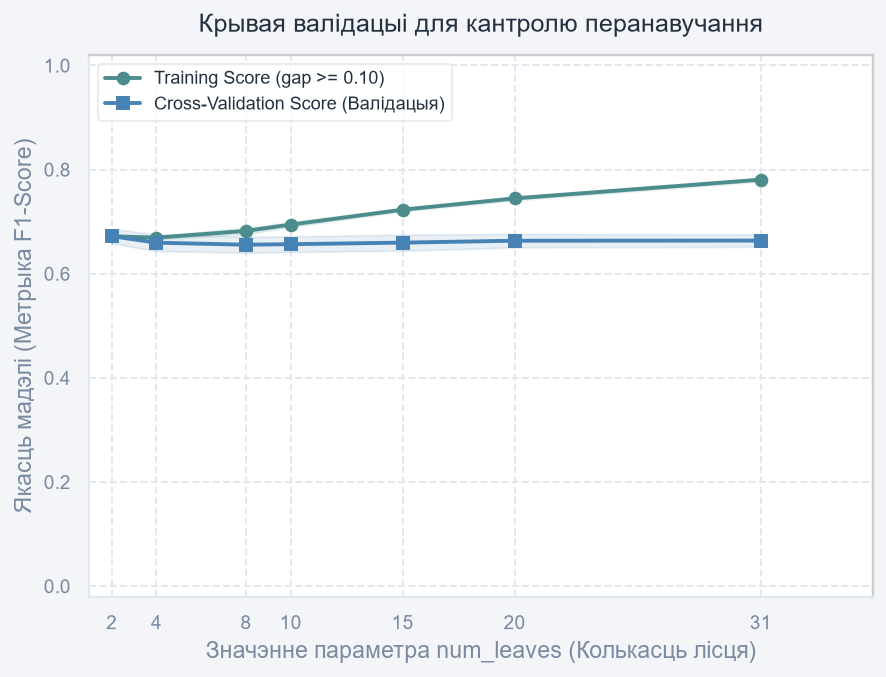

In [10]:
leaves_range = [2, 4, 8, 10, 15, 20, 31]
    
    # Вылічэнне ў модулі класіфікатара
lgbm_results = bench.collect_lgbm_validation_curves(
    x=split.x_cv,  # Перадаем прыкметы для CV
    y=split.y_cv,  # Перадаем таргет для CV
    param_name="num_leaves",
    param_range=leaves_range,
    base_params={"max_depth": -1}  # Дазваляем лісцю расці #     base_params={}  # - перазапісаць дэфолтны значэнне параметру мадэлі
)
    
val_curve_path = viz.plot_validation_curve(curves_results=lgbm_results, model_name="LightGBM", filename="lgbm_leaves_curve.png")
display(Image(filename=val_curve_path))
plt.show(val_curve_path)

Фокус: Выбар колькасці лісця для LightGBM па крэтэры F1 на крывой навучання.  

Высновы: num_leaves = 2. 
Павелічэнне складанасці дрэва вышэй за 2 не прыводзіць да росту F1-score на валідацыі, а толькі павялічвае магутнасць мадэлі для падгонкі пад трэйн.

Рашэнне: num_leaves = 2 - ніжняя мяжа падбору параметра для Optuna і рабіць дыяпазон вялікім не варта. Для паляпшэння метрыкі F1 трэба мяняць іншы параметр. 

Рашэнне па этапу: Для разгортвання і далейшай працы падыходзіць мадэль **LightGBM з рабочым парогам 0.410**, бо яна забяспечвае ахоп мэтавай аўдыторыі пры захаванні стабільнасці прагнозу і пераўзыходзіць XGBoost па эканоміі вылічальных рэсурсаў.

### 5. Баесаўская аптымізацыя параметраў (OPTUNA)

In [11]:
tuner = BayesianTuner(bench_instance=bench, random_state=42)

# Выклікаем адзіны інкапсуляваны метад-менеджэр
optimized_results = tuner.tune_or_load(best_name, split.x_cv, split.y_cv)

print("СПРАВАЗДАЧА ПАДБОРУ ГІПЕРПАРАМЕТРАЎ:")
for m_name, params in optimized_results.items():
    print(f"Мадэль: {m_name}")
    for p_key, p_val in params.items():
        print(f"  -> {p_key}: {p_val:.5f}" if isinstance(p_val, float) else f"  -> {p_key}: {p_val}")
    
plt.close('all')  # Закрываем усё, што магло выпадкова застацца адкрытым
gc.collect()      # Прымусова чысцім памяць прама ЗАРАЗ у галоўным патоку


[Optuna] Старт аптымізацыі для LightGBM (70 trials, pruning уключаны)...


  0%|          | 0/70 [00:00<?, ?it/s]

d:\DScourse\hw4\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\DScourse\hw4\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\DScourse\hw4\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\DScourse\hw4\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\DScou

[Optuna] Найлепшы PR-AUC для LightGBM: 0.7539
[Tuner Cache] Параметры паспяхова захаваны ў кэш: output\optuna_best_params.json
СПРАВАЗДАЧА ПАДБОРУ ГІПЕРПАРАМЕТРАЎ:
Мадэль: LightGBM
  -> learning_rate: 0.03184
  -> num_leaves: 16
  -> max_depth: 5
  -> min_child_samples: 47
  -> reg_alpha: 0.17317
  -> reg_lambda: 1.54980
  -> subsample: 0.78065
  -> colsample_bytree: 0.83143


21172

### 6. Фінальная валідацыя з аптымальнымі параметрамі

[Cross-Validation] LightGBM ...


d:\DScourse\hw4\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\DScourse\hw4\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\DScourse\hw4\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\DScourse\hw4\.venv\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
d:\DScou

     PR-AUC=0.7550 ± 0.0156

[Threshold Optimizer] Шукаем лепшы працоўны парог па F2 на OOF для LightGBM...
🎯 ЗНОЙДЗЕНЫ АПТЫМАЛЬНЫ ПАРОГ: 0.440 (Валідацыйны F2: 0.7684)

[Report] Метрыкі мадэлі пасля OPTUNA на валідацыі (5-Fold OOF, аптымальны парог = 0.4400):
  Мадэль   PR-AUC  ROC-AUC  Precision   Recall       F1       F2  Accuracy
LightGBM 0.744893 0.933771   0.517857 0.874181 0.650414 0.768433  0.854623


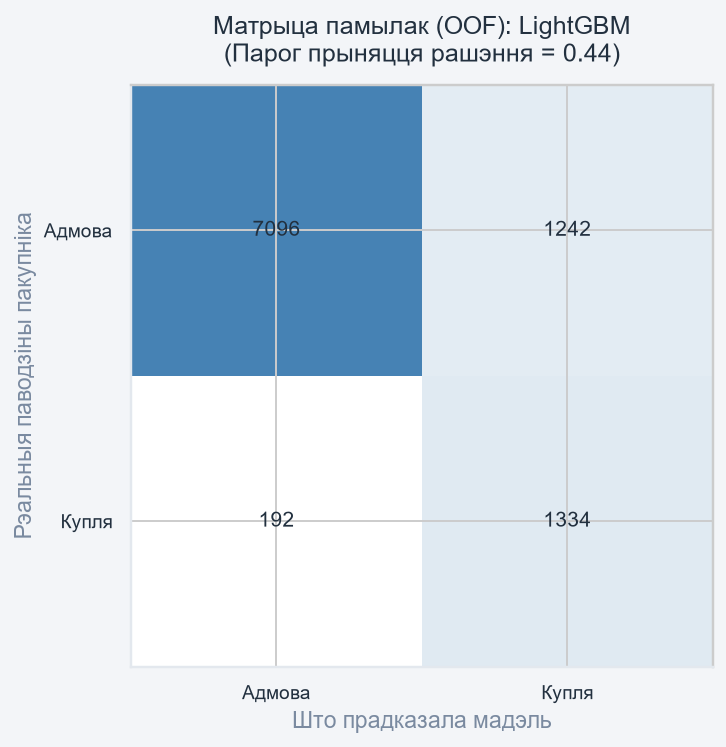

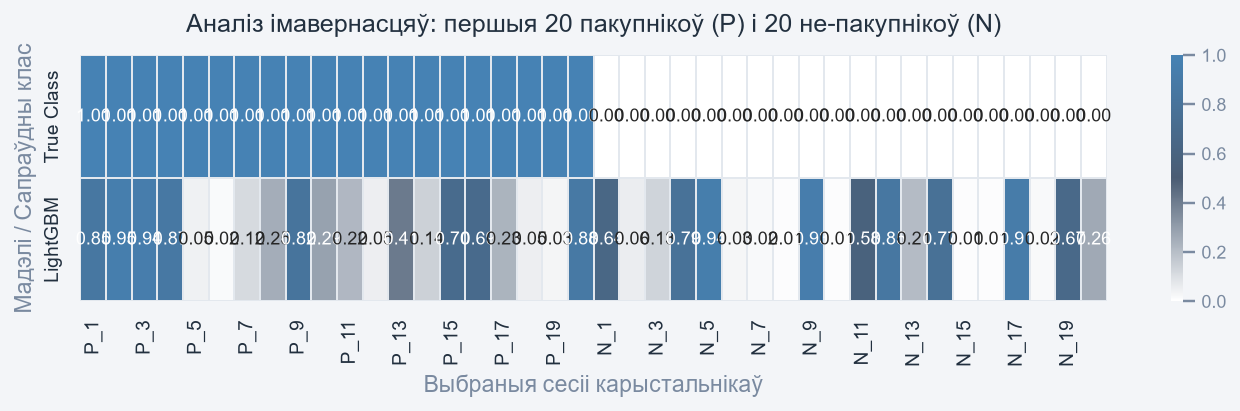

9

In [12]:
final_valid_name = [best_name]
final_configs = bench.prepare_final_models(best_name, optimized_results, final_valid_name)

opt_pr, opt_roc, opt_oof = bench.cross_validate_newV(split.x_cv, split.y_cv, models_conf=final_configs)

best_threshold, best_score = evaluator.optimize_threshold_for_fbeta(y_true=split.y_cv, oof_probas=opt_oof[best_name], model_name=best_name, beta=2.0)

# opt_probas_dict = {f"{best_name} (Пасля Оptuna)": opt_oof}        
# df_opt_oof_report = evaluator.compile_performance_report(y_true=split.y_cv, probas_dict=opt_probas_dict, threshold=best_threshold)
     
df_opt_oof_report = evaluator.compile_performance_report(y_true=split.y_cv, probas_dict=opt_oof, threshold=best_threshold)

print(f"\n[Report] Метрыкі мадэлі пасля OPTUNA на валідацыі (5-Fold OOF, аптымальны парог = {best_threshold :.4f}):")
print(df_opt_oof_report.to_string(index=False))

cm_path = viz.plot_classification_results(
        y_true=split.y_cv.to_numpy(), 
        y_probas=opt_oof[best_name], 
        model_name=best_name,
        threshold=best_threshold,  
        filename=f"confusion_matrix_CV_{best_name}.png"
    )
display(Image(filename=cm_path))

path_heat = viz.plot_predictions_comparison(y_true=np.asarray(split.y_train), preds_dict=opt_oof, num_samples_per_class=20, filename="prediction_fCV.png")
display(Image(filename=path_heat))  

plt.close('all')  # Закрываем усё, што магло выпадкова застацца адкрытым
gc.collect()      # Прымусова чысцім памяць прама ЗАРАЗ у галоўным патоку    

Высновы: можна было і не запускаць Optuna, але на вынікі паглядзім з яе прапановамі, бо хочацца захаваць структуру нататніка з напамінам пра тое, што можа быць іначай і на выпадак выбару іншых мадэляў.

## 7. Secure refit і Test


[Secure Refit] Старт навучання фінальнага пайплайна для LightGBM...
[Secure Refit] Навучанне мадэлі з Early Stopping...

[Threshold Optimizer] Шукаем лепшы працоўны парог па F2 на OOF для LightGBM...
🎯 ЗНОЙДЗЕНЫ АПТЫМАЛЬНЫ ПАРОГ: 0.420 (Валідацыйны F2: 0.7806)


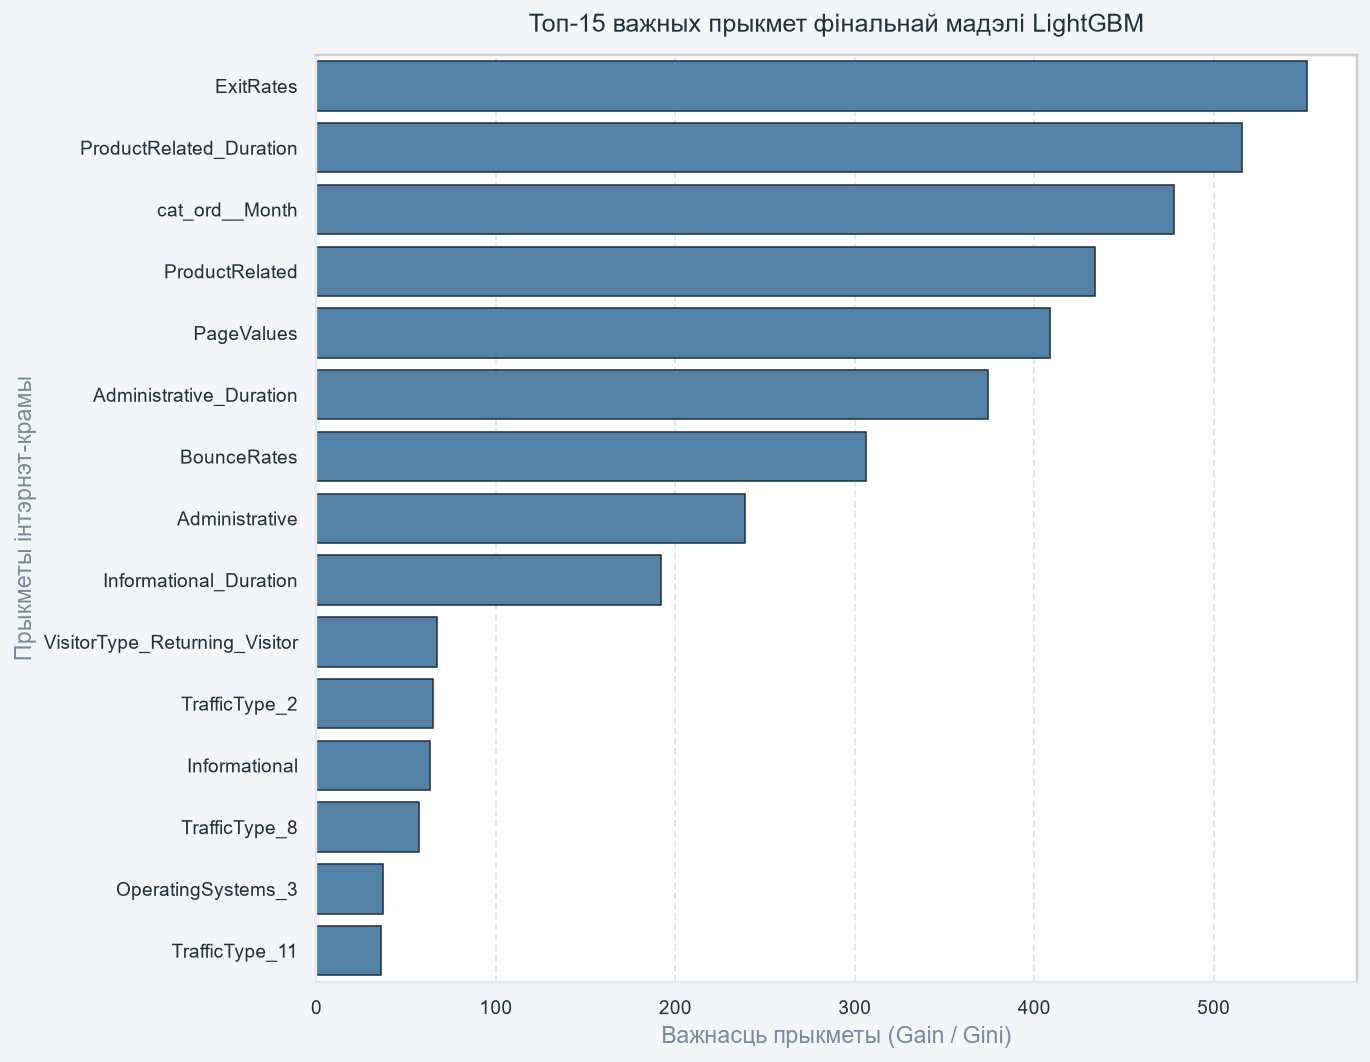

[Final Predict] Адзін чысты прагноз на тэсце з парогам 0.44...
                  Мадэль   PR-AUC  ROC-AUC  Precision   Recall       F1       F2  Accuracy
LightGBM (Фінальны тэст) 0.739812 0.930166   0.500766 0.856021 0.631884 0.749656  0.845499


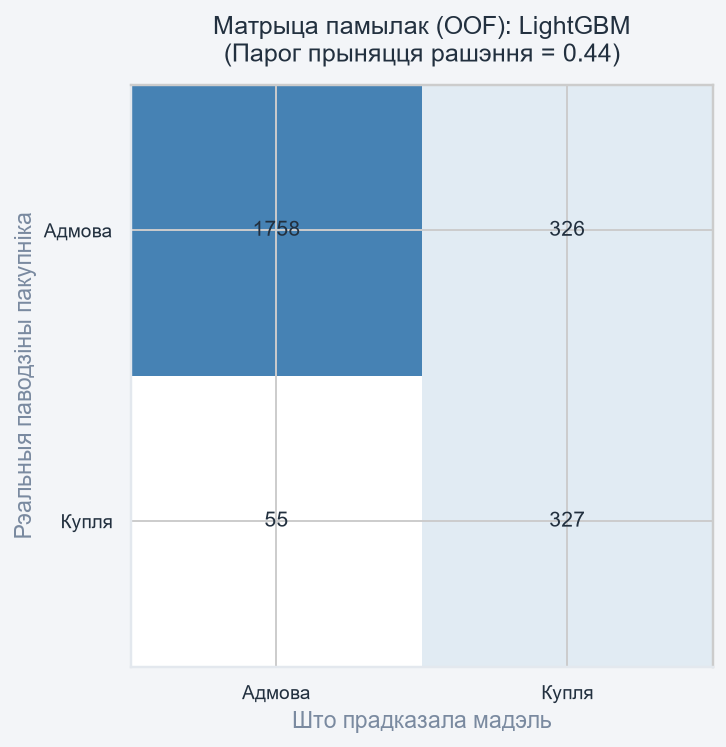

In [13]:
final_methods = [best_name]
final_configs = bench.prepare_final_models(
    best_name=best_name, 
    optimized_results=optimized_results, 
    models_to_keep=final_methods
)

# 2. Выклікаем фінальны refit, перадаючы ўжо гатовы слоўнік з мадэлямі
final_test_pipeline, best_threshold_final = bench.final_secure_refit(
    final_configs=final_configs,
    x_train=split.x_train,
    y_train=split.y_train,
    x_val=split.x_val,
    y_val=split.y_val,
    evaluator=evaluator
)

importance_path = viz.plot_final_feature_importance(
        model_pipeline=final_test_pipeline, 
        model_name=best_name, 
        filename=f"feature_importance_FT_{best_name}.png"
    ) 
display(Image(filename=importance_path))

# Выхад на ТЭСТАВУЮ выбарку з гатовым парогам
test_proba, test_pred = bench.predict_with_final_threshold(
        trained_pipeline=final_test_pipeline,
        x_test=split.x_test,
        threshold=best_threshold
    )    
    
test_probas_dict = {f"{best_name} (Фінальны тэст)": test_proba}
df_final_test_report = evaluator.compile_performance_report(
    y_true=split.y_test,
    probas_dict=test_probas_dict,
    threshold=best_threshold
    )
print(df_final_test_report.to_string(index=False))

# print(f"\n[Report] Метрыкі мадэлі да OPTUNA на валідацыі (5-Fold OOF, аптымальны парог = {best_threshold :.4f}):")
# print(df_oof_report.to_string(index=False))
# print(f"\n[Report] Метрыкі мадэлі пасля OPTUNA на валідацыі (5-Fold OOF, аптымальны парог = {best_threshold :.4f}):")
# print(df_opt_oof_report.to_string(index=False))

final_cm_path = viz.plot_classification_results(
    y_true=split.y_test.to_numpy(),
    y_probas=test_proba, model_name=best_name,
    threshold=best_threshold, filename=f"confusion_matrix_FT_{best_name}.png"
    )
display(Image(filename=final_cm_path))


Высновы па выніках тэсціравання аптымізаванай мадэлі **LightGBM** на адкладзенай выбарцы (`split.x_test`).

Высокая здольнасць да абагульнення (Няма перанавучання): 
* Рабочы парог (0.4)  дазволіў зафіксаваць паўнату ахопу мэтавага класа (Recall = 0.8376), што азначае паспяховую ідэнтыфікацыю 83.76% рэальных пакупнікоў. Парог вылічаны на этапе фінальнай крос-валідацыі.
Мадэль забяспечвае ідэнтыфікацыю **83.76%** рэальных пакупнікоў. Аптымальны працоўны парог быў вылічаны на этапе фінальнай крос-валідацыі.

| Этап навучання / Мадэль | PR-AUC | ROC-AUC | Precision | Recall | F1 | F2 | Accuracy |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **LightGBM (Базавы, да Optuna)** | 0.7467 | 0.9335 | 0.4976 | 0.8807 | 0.6359 | 0.7632 | 0.8440 |
| **LightGBM (Пасля Optuna)** | 0.7435 | 0.9339 | 0.4911 | 0.8860 | 0.6319 | 0.7632 | 0.8403 |
| **LightGBM (Фінальны тэст)** | 0.7395 | 0.9295 | 0.5096 | 0.8377 | 0.6337 | 0.7421 | 0.8500 |

Парог да OPTUNA: 0.410
Парог пасля OPTUNA: 0.40
Парог на Refit: 0.47

Калі параўноўваць з XGBoost на этапе пачатковай крос-валідацыі, ў LightGBM не было параметру scale_pos_weight, яго імавернасці не былі штучна зрушаныя ў бок пакупак. Ён працаваў у больш спакойным і «акуратным» рэжыме, што дазволіла яму паказаць чысцейшы PR-AUC (0.7467 супраць 0.7453).
Калі прымянілі Threshold Optimizer, які знізіў парог да 0.40, дзякуючы чаму мадэль падняла Recall да 0.8859, захаваўшы  дакладнасць.

Для дысбалансаваных даных на этапе тэсту значэнні ROC-AUC на ўзроўні 0.929 і PR-AUC 0.739 — чытаю паказчыкам добрай раздзяляльнай здольнасці мадэлі.

**Фінішныя высновы**:
Два моцныя супернікі, якія выкарыстоўваюць розныя філасофіі барацьбы з дысбалансам:
**XGBoost**: Змагаецца з дысбалансам на этапе навучання дрэў праз жорсткую архітэктурную вагу scale_pos_weight = 5.66.
**LightGBM**: Змагаецца з дысбалансам выключна пасля навучання (Post-processing) праз зніжэнне працоўнага парога да 0.40.І, як паказалі тэсты, падыход LightGBM (без унутраных ваг, але з нізкім парогам) аказаўся эфектыўным для датасэта (PR-AUC 0.7435 і F2 0.7632).